<a href="https://colab.research.google.com/github/Yash-Verma-721/Data_Visualization_Project/blob/main/Netflix_Content_Analysis_Trends_and_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix Content Analysis: Trends and Insights

This project explores Netflix's content distribution, growth trends, and genre patterns to uncover insights about its content strategy and global presence.



## Dataset Overview

- Source: Netflix Titles Dataset
- Total Records: ~8800
- Key Features:
  - Type (Movie / TV Show)
  - Country
  - Date Added
  - Genre (listed_in)
  - Duration & Rating

### Load the Dataset

In [ ]:
import pandas as pd

df = pd.read_csv("/netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Understanding the Data

In this section, we examine:
- Data types of each column to ensure correct processing
- Missing values, as they can lead to biased or incomplete visualizations

Initial observations:
- 'director' has a large number of missing values (~2600), which may limit analysis involving directors
- 'cast' and 'country' also contain significant missing data
- Other columns have minimal or no missing values

These missing values will need to be handled appropriately before visualization (e.g., filling with 'Unknown' or excluding where necessary).

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


## Data Cleaning

In this section, we perform data cleaning to improve data quality and ensure reliable analysis:

- Remove duplicate records to avoid redundant entries
- Handle missing values based on column context

Cleaning decisions:
- 'director', 'cast', and 'country' → filled with 'Unknown' due to high missing values
- Other columns → left unchanged or handled separately depending on their data type


In [ ]:
df.drop_duplicates(inplace=True)

# Fill only high-missing categorical columns to preserve dataset size
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

### Fix Date Column

In this section, we convert the 'date_added' column to datetime format to enable time-based analysis.

- Convert 'date_added' to datetime format
- Extract 'year_added' to analyze trends over time
- Handle invalid date values using coercion

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Check how many values failed conversion
missing_dates = df['date_added'].isnull().sum()
print("Missing date values after conversion:", missing_dates)

df['year_added'] = df['date_added'].dt.year.astype('Int64')
df


Missing date values after conversion: 98


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020


The 'date_added' column contained ~1% missing values (98 out of 8807 rows).
Since this proportion is very small, removing these rows does not significantly impact the dataset.

Dropping these entries ensures cleaner and more reliable time-based analysis,
without introducing artificial or misleading data through imputation.

In [ ]:
df = df.dropna(subset=['date_added'])


## Exploratory Data Analysis (EDA)

### Distribution of Content Type (Movies vs TV Shows)

In this section, we analyze the distribution of content types available on Netflix
to understand whether the platform is dominated by movies or TV shows.

Observation:
- Movies (6131) significantly large amount than TV Shows (2578)
- Movies make up a large majority of the content.

Insight:
- Netflix appears to focus more on movie content than TV shows
- This may indicate a strategy of maintaining a large movie library while selectively producing or acquiring TV series


In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2578


### Distribution of content over top 10 Countries
In this section, we analyze the distribution of content  available on Netflix to understand whether the platform has widely on the top Countries.

Observation:
- The United States has the highest number of titles (2778), followed by India (971)
- A large number of entries (827) are labeled as 'Unknown'

Insights:
- The United States contributes a disproportionately large share of content compared to other countries, far exceeding the second-ranked country (India).
- This suggests Netflix's content library is heavily  toward U.S.-produced content.
- Netflix content is heavily dominated by U.S. productions, with a large gap between the U.S. and other countries.
- The dataset contains a significant amount of missing country information ('Unknown'), which may affect the accuracy of geographic analysis


In [ ]:
df['country'].value_counts().head(10)

,count
country,
United States,2778
India,971
Unknown,827
United Kingdom,403
Japan,241
South Korea,195
Canada,173
Spain,141
France,122


### Distribution of content over the Years
In this section, we analyze the distribution of content available on Netflix to understand in which year the production is increases.

Observation:
- Content additions were very low before 2015
- There is a  increases in content from 2016 onwards
- Content additions peak around 2019
- After 2019, there is a noticeable decline in content additions

Insights:
- Netflix experienced rapid growth in content additions between 2016 and 2019
- The peak in 2019 suggests a period of aggressive content expansion
- The decline after 2019 may indicate a slowdown in content additions or external factors affecting production
* NetFlix content is slightly goes down by the year 2019.
* Currently NetFlix content production is geting low then previous 2 years.

In [ ]:
df['year_added'].value_counts().sort_index()

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,10
2014,23
2015,73
2016,418


## Visualization

### Import the important python class for visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

**1. This plot shows the distribution of Movies and TV Shows on Netflix.**

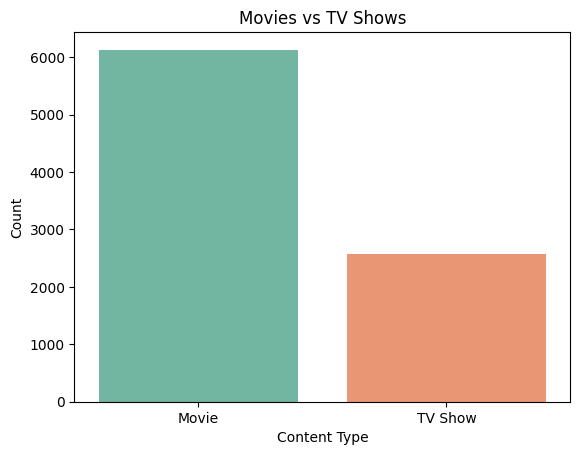

In [ ]:
# 1. Movies vs TV Shows
sns.countplot(x='type', data=df, hue='type', palette='Set2', legend=False)
plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

This visualization confirms that movies dominate Netflix content.

- Movies significantly outnumber TV Shows.
- The difference is visually more apparent compared to raw numbers.
- This highlights Netflix’s stronger focus on movie content.

---------

 **2. This plot shows the top 10 countries contributing the most content on Netflix.**


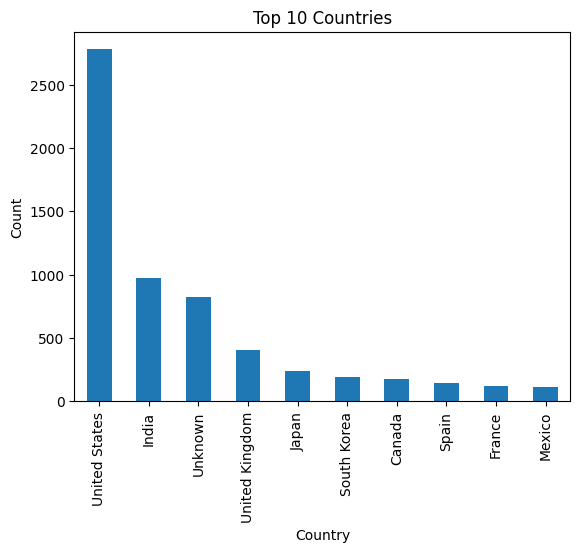

In [ ]:
# 2. Top 10 Countries
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

### Observation:
* The United States dominates Netflix content, contributing significantly more titles than any other country.

* India ranks second, but there is a large gap between the United States and all other countries.

* A notable number of entries are labeled as 'Unknown', indicating missing country information, which may affect the accuracy of country-based analysis.

---

**3. This plot shows content growth over a years on Netflix.**

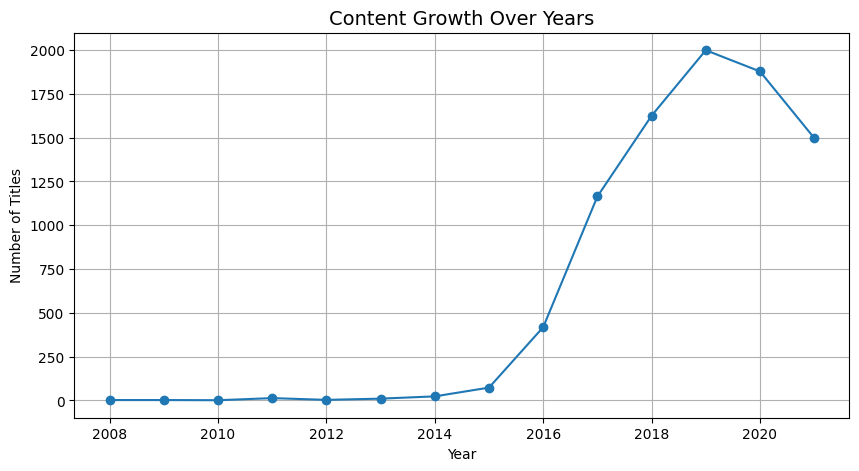

In [ ]:
# 3. Content Growth Over Time
year_data = df['year_added'].value_counts().sort_index() # Sort years chronologically to correctly visualize trends over time
plt.figure(figsize=(10,5))
year_data.plot(marker='o')
plt.grid()
plt.title("Content Growth Over Years", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

- Content additions increase significantly after 2016
- Peak observed around 2019

- The visualization clearly highlights the sharp growth in content additions after 2016
- The peak around 2019 becomes more evident visually
- A declining trend after 2019 can also be observed

---

  ### **4. This plot shows Movies vs TV Shows by Country**

In this section, we compare the distribution of Movies and TV Shows across the top countries
to understand regional content patterns on Netflix.

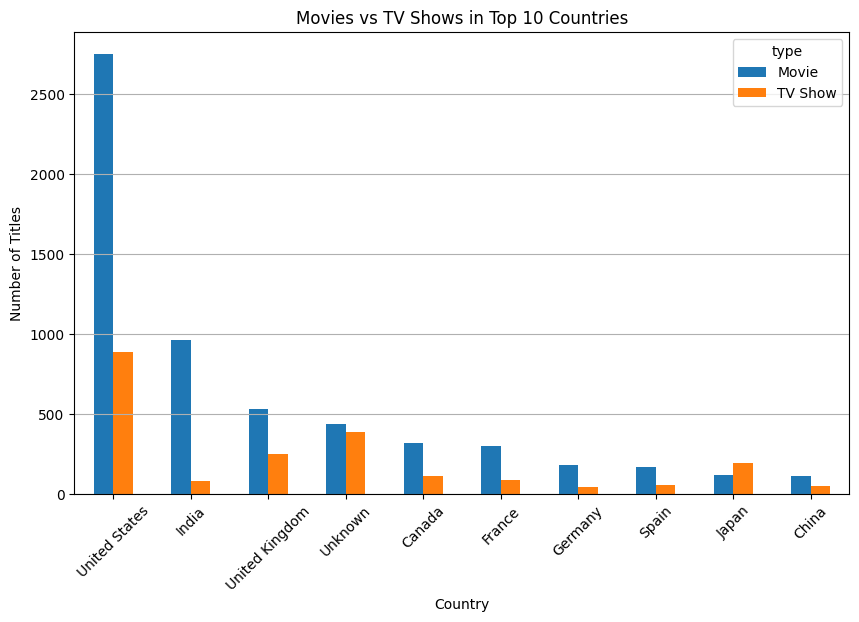

In [ ]:
# Split multiple countries into separate rows
df['country'] = df['country'].str.split(',')
df = df.explode('country')

# Group by country and content type
country_type = df.groupby(['country', 'type']).size().unstack()

# Fill missing values
country_type = country_type.fillna(0)

# Get top 10 countries based on movie count
top_10 = country_type.sort_values(by='Movie', ascending=False).head(10)

# Plot
top_10.plot(kind='bar', figsize=(10,6))
plt.title("Movies vs TV Shows in Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

Insights:

- The United States dominates in both Movies and TV Shows, contributing significantly more content than other countries.

- Movies are more prevalent than TV Shows across most countries, indicating a global preference or higher production of movies.

- India shows a strong presence in Movies but relatively fewer TV Shows.

- Countries like Japan  have a comparatively higher proportion of TV Shows.

- The variation across countries suggests differences in regional content strategies and audience preferences.

---

**5. This plot shows a comparative visualization between Movies & TV Shows Over Time**

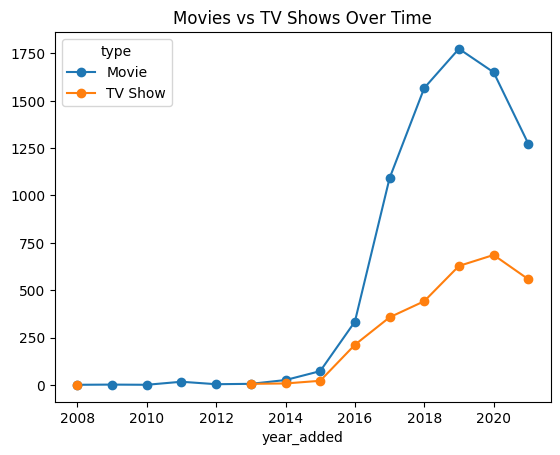

In [ ]:
df.groupby(['year_added', 'type']).size().unstack().plot(marker='o')
plt.title("Movies vs TV Shows Over Time")
plt.show()

Insights:

- Movies experienced a much sharper growth compared to TV Shows, especially after 2016, indicating a stronger expansion focus on movie content.

- The gap between Movies and TV Shows widens significantly after 2016, showing that Movies scaled at a much faster rate than TV Shows.

- TV Shows show a more gradual and steady increase over time, suggesting a more consistent but slower growth strategy compared to Movies.

- While both Movies and TV Shows peak around a similar time period, the decline in Movies is more pronounced than in TV Shows.

- The trend indicates that Netflix expanded both content types, but Movies remained the dominant driver of overall content growth.

---

**6. This plot shows the Top Geners of NetFlix.**

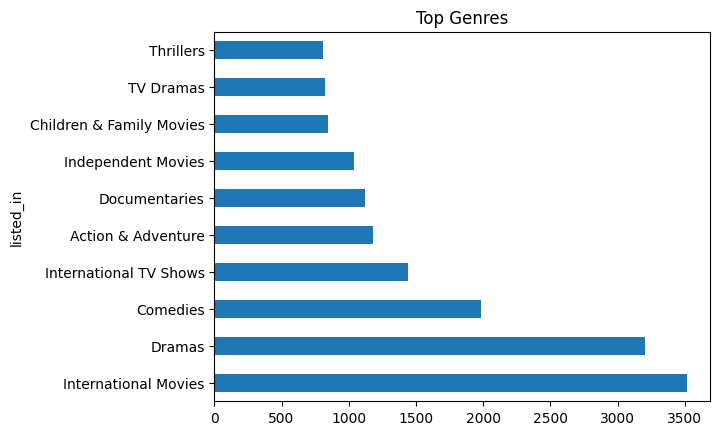

In [ ]:
df['listed_in'] = df['listed_in'].str.split(',')
df = df.explode('listed_in')
df['listed_in'] = df['listed_in'].str.strip()

df['listed_in'].value_counts().head(10).plot(kind='barh')
plt.title("Top Genres")
plt.show()

Insights:

- International Movies and Dramas dominate the platform, indicating a strong focus on globally appealing and story-driven content.

- The presence of both "International Movies" and "International TV Shows" in top categories highlights Netflix’s strategic emphasis on global content distribution.

- Drama and Comedy appear as core content pillars, suggesting that narrative-driven and entertainment-focused genres form the backbone of Netflix’s library.

- The mix of genres like Documentaries, Action & Adventure, and Independent Movies shows that Netflix maintains diversity beyond mainstream categories.

- The relatively lower counts of niche genres (e.g., Thrillers, Children & Family Movies) suggest that while present, they are not the primary drivers of content volume.

- The dominance of broad categories like Drama and International Movies suggests that Netflix prioritizes scalable, widely consumable content over highly specialized genres.

---

## Key Findings

- Netflix content is dominated by Movies over TV Shows across most regions.
- The United States is the primary contributor, followed by India and other countries.
- Content growth increased sharply after 2016, peaking around 2019.
- International content plays a major role in Netflix’s library.
- Drama and International Movies are the most prominent genres.

---

## Conclusion

Netflix has significantly expanded its content library over the years, with a strong emphasis on Movies and globally distributed content.
The platform shows a clear strategy of targeting international audiences while maintaining dominance in key regions like the United States and India.
The content trends indicate a shift toward scalable and widely consumable genres such as Drama and International Movies.

---

## Limitations

- Presence of missing values (e.g., 'Unknown' country)
- Dataset may not reflect latest Netflix catalog

---

## Future Work

- Analyze ratings and audience preferences
- Perform recommendation-based analysis